<a href="https://colab.research.google.com/github/CrUz-035/Optuna-Registro-de-Experimentos-y-Regularizaci-n/blob/main/Tarea_3_Redes_Neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tarea 3. Optuna, Registro de experimentos y Regularización


Francisco Romero Mestiza

Redes Neuronales

28/02/2026

1. Diseñar una red Densa secuencial (No convolucional) para clasificación de dígitos (mnist) e
implementarla en Keras.
(a) Emplear Optuna para para realizar varios experimentos y buscar encontrar una buena
arquitectura de red. Es decir, probar distintos numeros de capas, neuronas, cambiar fun
ciones de activación y optimizador. Es cuestión de tu creatividad. No usar regularización
en esta etapa!!. Registrar los experimentos en MLflow o WandB. En el reporte
indicar el enlace del servidor (Dagshub, WandB u otro) donde se puedan ver las gráficas
del experimento.

In [ ]:
!pip install optuna #instalamos optuna
import optuna
!pip install -q mlflow #Instalamos Mlflow
import mlflow
! pip install jupyterlab jupyterlab-optuna

mlflow.tensorflow.autolog()

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Input
#Importamos las funciones a ocupar en el entrenamiento.
from tensorflow.keras.optimizers import RMSprop, SGD, Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
def objective(trial):  # función objetivo que optimiza Optuna
    with mlflow.start_run(nested=True):  # inicia un run en MLflow
        model = Sequential()  # modelo secuencial
        # número de capas ocultas (1 o 2)
        n_layers = trial.suggest_int("n_layers", 1, 2)
        for i in range(n_layers):
            # número de neuronas por capa
            n_units = trial.suggest_int(f"n_units_l{i}", 64, 512)
            # función de activación
            activation = trial.suggest_categorical(
                f"activation_l{i}", ["relu", "tanh", "sigmoid"]
            )
            # primera capa necesita input_shape
            if i == 0:
                model.add(Dense(n_units, activation=activation, input_shape=(784,)))
            else:
                model.add(Dense(n_units, activation=activation))
        # capa de salida (clasificación multiclase)
        model.add(Dense(10, activation="softmax"))
        #  optimizador
        optimizer_name = trial.suggest_categorical(
            "optimizer", ["Adam", "SGD", "RMSprop"]
        )
        # learning rate
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        if optimizer_name == "Adam":
            optimizer = Adam(learning_rate=lr)
        elif optimizer_name == "SGD":
            optimizer = SGD(learning_rate=lr)
        else:
            optimizer = RMSprop(learning_rate=lr)
        # compilación del modelo
        model.compile(
            loss="categorical_crossentropy",
            optimizer=optimizer,
            metrics=["accuracy"]
        )
        # entrenamiento
        history = model.fit(
            x_trainv, y_trainc,
            validation_split=0.2,
            epochs=10,
            batch_size=128,
            verbose=0
        )
        # mejor accuracy de validación
        val_acc = max(history.history["val_accuracy"])
        mlflow.log_metric("val_accuracy", val_acc)  # guardar métrica
        return val_acc  # Optuna maximiza esto

In [ ]:
dataset=mnist.load_data() #La base de datos de mnist es nuestro dataset
(x_train, y_train), (x_test, y_test) = dataset
x_trainv = x_train.reshape(60000, 784)
x_testv = x_test.reshape(10000, 784)
x_trainv = x_trainv.astype('float32')
x_testv = x_testv.astype('float32')

x_trainv /= 255.  # x_trainv = x_trainv/255
x_testv /= 255. #Se normalizan los datos

num_classes=10 #Los 10 dígitos.
y_trainc = keras.utils.to_categorical(y_train, num_classes)
y_testc = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15) #se optimiza la función objetive.

print("Mejores parámetros:")
print(study.best_params) #Los mejores parámetros

[I 2026-03-01 04:45:12,349] A new study created in memory with name: no-name-e2b7c610-b0bb-4392-b01e-ed96cfb927e6
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


2026/03/01 04:46:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
[I 2026-03-01 04:46:42,989] Trial 0 finished with value: 0.8480833172798157 and parameters: {'n_layers': 2, 'n_units_l0': 281, 'activation_l0': 'relu', 'n_units_l1': 505, 'activation_l1': 'tanh', 'optimizer': 'SGD', 'lr': 0.0007341130959061941}. Best is trial 0 with value: 0.8480833172798157.


🏃 View run resilient-croc-939 at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/d34f738a241f4307a88a182a5cf85453
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


...

2026/03/01 05:05:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
[I 2026-03-01 05:05:53,333] Trial 13 finished with value: 0.9764999747276306 and parameters: {'n_layers': 1, 'n_units_l0': 138, 'activation_l0': 'relu', 'optimizer': 'RMSprop', 'lr': 0.0016692715024133181}. Best is trial 4 with value: 0.981333315372467.


🏃 View run sneaky-skink-682 at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/426083b323984069a32202dad0183836
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


2026/03/01 05:07:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
[I 2026-03-01 05:07:31,225] Trial 14 finished with value: 0.9767500162124634 and parameters: {'n_layers': 1, 'n_units_l0': 346, 'activation_l0': 'relu', 'optimizer': 'RMSprop', 'lr': 0.0005304836579651789}. Best is trial 4 with value: 0.981333315372467.


🏃 View run calm-mole-442 at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/c547185b70fe4f929b81106e2acf50ea
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1
Mejores parámetros:
{'n_layers': 1, 'n_units_l0': 219, 'activation_l0': 'relu', 'optimizer': 'RMSprop', 'lr': 0.0019954857471173276}


In [ ]:
!pip install -U kaleido
#Se immportan las herramientas necesarias para mostrar las gráficas
import matplotlib.pyplot as plt
from optuna.visualization import plot_optimization_history, plot_param_importances
from optuna.visualization import plot_parallel_coordinate, plot_contour
from optuna.visualization import plot_slice, plot_edf

fig1 = plot_optimization_history(study)
fig1.show()

# 2. Importancia de los hiperparámetros
fig2 = plot_param_importances(study)
fig2.show()

# 3. Coordenadas paralelas (relación entre parámetros y resultados)
fig3 = plot_parallel_coordinate(study)
fig3.show()

# 4. Gráfica de contorno (interacción entre 2 parámetros)
fig4 = plot_contour(study, params=['n_units_l0', 'lr'])
fig4.show()

# 5. Gráfica de slice (distribución de resultados por parámetro)
fig5 = plot_slice(study)
fig5.show()


/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




#Subir experimentos a Dagshub

In [ ]:
REPO_NAME= "tarea_3"
REPO_OWNER = "CrUz-035"
USER_NAME = "CrUz-035"

In [ ]:
!pip install mlflow --quiet

In [ ]:
import mlflow
import os
from getpass import getpass

os.environ['MLFLOW_TRACKING_USERNAME'] = USER_NAME
os.environ['MLFLOW_TRACKING_PASSWORD'] = getpass('Enter your DAGsHub access token or password: ')

mlflow.set_tracking_uri(f'https://dagshub.com/{REPO_OWNER}/{REPO_NAME}.mlflow')

Enter your DAGsHub access token or password: ··········


In [ ]:
mlflow.tensorflow.autolog()


In [ ]:
! pip3 install dagshub --upgrade


In [ ]:
import mlflow
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate, plot_contour, plot_slice, plot_edf

# Iniciar un nuevo MLflow run para guardar las visualizaciones del estudio de Optuna
with mlflow.start_run(run_name="Optuna_Study_Visualizations"):

    fig1 = plot_optimization_history(study)
    mlflow.log_figure(fig1, "optimization_history.html")

    fig2 = plot_param_importances(study)
    mlflow.log_figure(fig2, "param_importances.html")

    fig3 = plot_parallel_coordinate(study)
    mlflow.log_figure(fig3, "parallel_coordinate.html")

    try:
        fig4 = plot_contour(study, params=['n_units_l0', 'lr'])
        mlflow.log_figure(fig4, "contour_n_units_l0_lr.html")
    except ValueError:
        pass

    fig5 = plot_slice(study)
    mlflow.log_figure(fig5, "slice_plot.html")

    fig6 = plot_edf(study)
    mlflow.log_figure(fig6, "edf_plot.html")

🏃 View run Optuna_Study_Visualizations at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/d40c4dca24de4c1dbf0443b5106444db
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


(b) De la mejor red que hayas entrenado del inciso anterior. Entrena la red con los mismos
datos de entrenamiento pero usando regularizaciones:

• Primero: regularización L1

• Segundo: regularización L2

• Tercero: regularización L1-L2

• Cuarto: Dropout

• Quinto: Dropout y L1- L2

En el reporte comenta el resultado de cada caso. Es decir, ¿la regularización ayudó a
mejorar la eficiencia antes de haber sobreajuste? Registra tus experimentos con
MLflow o WandB y entrega también el enlace al registro de los experimentos

El mejor exp, consiste en:

Mejores parámetros:

{'n_layers': 1, 'n_units_l0': 219, 'activation_l0': 'relu', 'optimizer': 'RMSprop', 'lr': 0.0019954857471173276}

In [ ]:
x_trainv = x_train.reshape(60000, 784)
x_testv = x_test.reshape(10000, 784)
x_trainv = x_trainv.astype('float32')
x_testv = x_testv.astype('float32')

x_trainv /= 255.  # x_trainv = x_trainv/255
x_testv /= 255.

num_classes=10
y_trainc = keras.utils.to_categorical(y_train, num_classes)
y_testc = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

Antes de regularización

In [ ]:
# Mejores parámetros de Optuna:
# {'n_layers': 1, 'n_units_l0': 219, 'activation_l0': 'relu', 'optimizer': 'RMSprop', 'lr': 0.0019954857471173276}

from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import RMSprop

lr = 0.0019954857471173276
optimizer_name = 'RMSprop'
optimizer = RMSprop(learning_rate=lr)

model_0 = Sequential()
model_0.add(Input(shape=(784,)))  # Las imágenes ya están aplanadas a 784
# Primera capa oculta con los parámetros de Optuna
model_0.add(Dense(219, activation='relu'))  # Corregido: 219 en lugar de 301
# Capa de salida
model_0.add(Dense(10, activation='softmax'))
# Compilación del modelo (usando el optimizador y LR de Optuna)
model_0.compile(
    loss='categorical_crossentropy',
    optimizer=RMSprop(learning_rate=lr),  # Corregido: RMSprop en lugar de Adam
    metrics=['accuracy']
)

model_0.summary()


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 219)            │       171,915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 10)             │         2,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,115 (680.14 KB)

 Trainable params: 174,115 (680.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# MLflow setup
mlflow.set_experiment("Regularization_Study")

filepath = "best_model.keras"
earlystop = EarlyStopping(monitor='val_loss', mode='min', restore_best_weights=True, patience=10, verbose=1)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

with mlflow.start_run(run_name="0_model"):

    history_0 = model_0.fit(
        x_trainv, y_trainc,
        batch_size=128,
        epochs=20,
        validation_data=(x_testv, y_testc),
        callbacks=[earlystop, checkpoint],
        verbose=1
    )

    mlflow.log_metric("final_val_accuracy",
                      max(history_0.history["val_accuracy"]))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8734 - loss: 0.4229
Epoch 1: val_loss improved from inf to 0.13956, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8735 - loss: 0.4225 - val_accuracy: 0.9564 - val_loss: 0.1396
Epoch 2/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9666 - loss: 0.1081
Epoch 2: val_loss improved from 0.13956 to 0.08188, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9666 - loss: 0.1081 - val_accuracy: 0.9751 - val_loss: 0.0819
Epoch 3/20
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9802 - loss: 0.0672
Epoch 3: val_loss did not improve from 0.08188
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9802 - loss: 0.0672 - val_accuracy: 0.9752 - val_loss: 0.0862
Epoch 4/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9850 - loss: 0.0475
Epoch 4: val_loss improved from 0.08188 to 0.08110, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9850 - loss: 0.0475 - val_accuracy: 0.9751 - val_loss: 0.0811
Epoch 5/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9893 - loss: 0.0339
Epoch 5: val_loss improved from 0.08110 to 0.07656, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9893 - loss: 0.0339 - val_accuracy: 0.9760 - val_loss: 0.0766
Epoch 6/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9912 - loss: 0.0275
Epoch 6: val_loss improved from 0.07656 to 0.07577, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9912 - loss: 0.0276 - val_accuracy: 0.9779 - val_loss: 0.0758
Epoch 7/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9937 - loss: 0.0217
Epoch 7: val_loss improved from 0.07577 to 0.07099, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9937 - loss: 0.0217 - val_accuracy: 0.9801 - val_loss: 0.0710
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9949 - loss: 0.0181
Epoch 8: val_loss improved from 0.07099 to 0.06857, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9949 - loss: 0.0181 - val_accuracy: 0.9808 - val_loss: 0.0686
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9959 - loss: 0.0133
Epoch 9: val_loss did not improve from 0.06857
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9959 - loss: 0.0133 - val_accuracy: 0.9789 - val_loss: 0.0836
Epoch 10/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9974 - loss: 0.0089
Epoch 10: val_loss did not improve from 0.06857
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9974 - loss: 0.0089 - val_accuracy: 0.9806 - val_loss: 0.0727
Epoch 11/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9980 - loss: 0.0076
Epoch 11: val_loss did not improve from 0.06857
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9979 - loss: 0.0076 - val_accuracy: 0.9806 - val_loss: 0.0794
Epoch 12/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9983 - loss: 0.0061
Epoch 12: val_loss did not improve fr

2026/03/01 05:21:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run 0_model at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/34246fdd80f44943b87f89671e2fc569
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


In [ ]:
import matplotlib.pyplot as plt

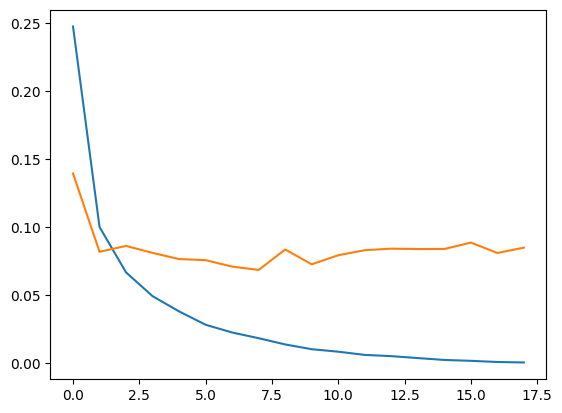

In [ ]:
plt.plot(history_0.history['loss'])
plt.plot(history_0.history['val_loss'])

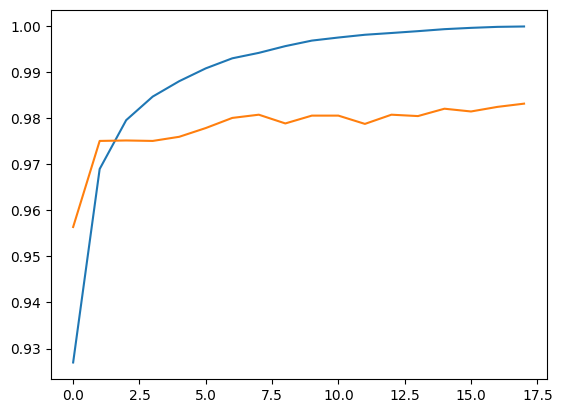

In [ ]:
plt.plot(history_0.history['accuracy'])
plt.plot(history_0.history['val_accuracy'])

L1

L1=0.000001 y 20 épocas

In [ ]:
#  Modelo con Regularización L1
# Basado en los mejores parámetros de Optuna:

# Mejores parámetros:
# {'n_layers': 1, 'n_units_l0': 219, 'activation_l0': 'relu',
#  'optimizer': 'RMSprop', 'lr': 0.0019954857471173276}

from tensorflow.keras.optimizers import RMSprop  # Importante: RMSprop, no Adam

lr = 0.0019954857471173276
optimizer_name = 'RMSprop' # RMSprop de Optuna

model_l1 = Sequential()
model_l1.add(Input(shape=(784,)))  # Las imágenes ya están aplanadas a 784

# ÚNICA capa oculta (n_layers=1) con los parámetros de Optuna+Regularización L1
model_l1.add(Dense(219,
                   activation='relu',
                   kernel_regularizer=regularizers.l1(0.000001)))  #L1=0.000001

# Capa de salida
model_l1.add(Dense(10, activation='softmax'))

# Compilación del modelo (usando el optimizador y LR de Optuna)
model_l1.compile(
    loss='categorical_crossentropy',
    optimizer=RMSprop(learning_rate=lr),  # CORREGIDO: RMSprop con LR de Optuna
    metrics=['accuracy']
)

model_l1.summary()


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 219)            │       171,915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 10)             │         2,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,115 (680.14 KB)

 Trainable params: 174,115 (680.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# MLflow setup
mlflow.set_experiment("Regularization_Study")

filepath = "best_model.keras"
earlystop = EarlyStopping(monitor='val_loss', mode='min', restore_best_weights=True, patience=10, verbose=1)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

with mlflow.start_run(run_name="l1.0_model"):

    history_l1 = model_l1.fit(
        x_trainv, y_trainc,
        batch_size=128,
        epochs=20,
        validation_data=(x_testv, y_testc),
        callbacks=[earlystop, checkpoint],
        verbose=1
    )

    mlflow.log_metric("final_val_accuracy",
                      max(history_l1.history["val_accuracy"]))

Epoch 1/20
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8735 - loss: 0.4323
Epoch 1: val_loss improved from inf to 0.14952, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8740 - loss: 0.4308 - val_accuracy: 0.9563 - val_loss: 0.1495
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9680 - loss: 0.1178
Epoch 2: val_loss improved from 0.14952 to 0.09282, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9680 - loss: 0.1178 - val_accuracy: 0.9731 - val_loss: 0.0928
Epoch 3/20
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9795 - loss: 0.0754
Epoch 3: val_loss improved from 0.09282 to 0.08160, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9795 - loss: 0.0754 - val_accuracy: 0.9766 - val_loss: 0.0816
Epoch 4/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9852 - loss: 0.0586
Epoch 4: val_loss improved from 0.08160 to 0.08096, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9852 - loss: 0.0586 - val_accuracy: 0.9792 - val_loss: 0.0810
Epoch 5/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9894 - loss: 0.0468
Epoch 5: val_loss did not improve from 0.08096
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9894 - loss: 0.0468 - val_accuracy: 0.9784 - val_loss: 0.0813
Epoch 6/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9905 - loss: 0.0397
Epoch 6: val_loss improved from 0.08096 to 0.07960, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9905 - loss: 0.0397 - val_accuracy: 0.9788 - val_loss: 0.0796
Epoch 7/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9928 - loss: 0.0317
Epoch 7: val_loss improved from 0.07960 to 0.07784, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9928 - loss: 0.0317 - val_accuracy: 0.9784 - val_loss: 0.0778
Epoch 8/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9947 - loss: 0.0258
Epoch 8: val_loss did not improve from 0.07784
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9947 - loss: 0.0258 - val_accuracy: 0.9790 - val_loss: 0.0843
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9953 - loss: 0.0248
Epoch 9: val_loss did not improve from 0.07784
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9953 - loss: 0.0248 - val_accuracy: 0.9784 - val_loss: 0.0838
Epoch 10/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9972 - loss: 0.0195
Epoch 10: val_loss improved from 0.07784 to 0.07706, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9972 - loss: 0.0195 - val_accuracy: 0.9803 - val_loss: 0.0771
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9976 - loss: 0.0186
Epoch 11: val_loss did not improve from 0.07706
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9976 - loss: 0.0186 - val_accuracy: 0.9813 - val_loss: 0.0851
Epoch 12/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9977 - loss: 0.0175
Epoch 12: val_loss did not improve from 0.07706
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9977 - loss: 0.0175 - val_accuracy: 0.9803 - val_loss: 0.0873
Epoch 13/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9988 - loss: 0.0140
Epoch 13: val_loss did not improve from 0.07706
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9988 - loss: 0.0140 - val_accuracy: 0.9818 - val_loss: 0.0814
Epoch 14/20
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9987 - loss: 0.0140
Epoch 14: val_loss did not impro

2026/03/01 05:41:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run l1.0_model at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/baba7f0db36b492f8f22cfdfec11708d
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


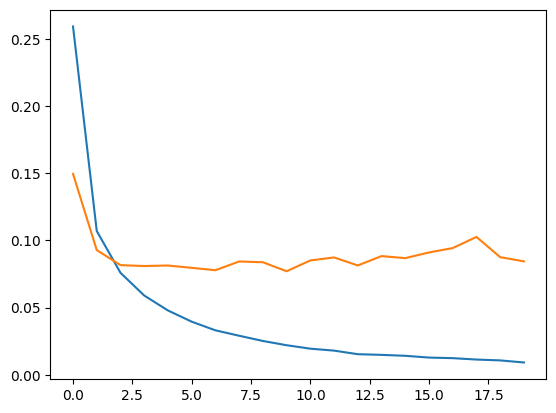

In [ ]:
plt.plot(history_l1.history['loss'])
plt.plot(history_l1.history['val_loss'])

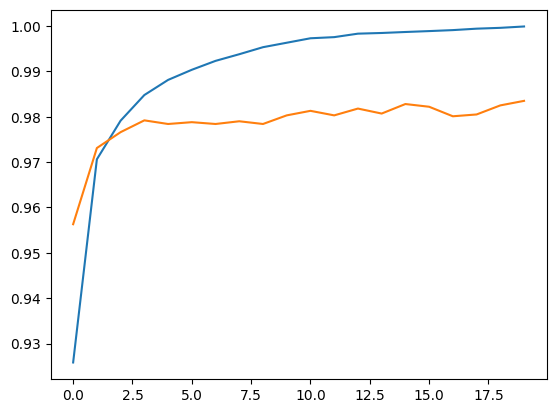

In [ ]:
plt.plot(history_l1.history['accuracy'])
plt.plot(history_l1.history['val_accuracy'])

L1=0.00001 , 20 epocas.


In [ ]:
#  Modelo con Regularización L1
# Basado en los mejores parámetros de Optuna:

# Mejores parámetros:
# {'n_layers': 1, 'n_units_l0': 219, 'activation_l0': 'relu',
#  'optimizer': 'RMSprop', 'lr': 0.0019954857471173276}

from tensorflow.keras.optimizers import RMSprop  # Importante: RMSprop, no Adam

lr = 0.0019954857471173276
optimizer_name = 'RMSprop' # RMSprop de Optuna

model_l1 = Sequential()
model_l1.add(Input(shape=(784,)))  # Las imágenes ya están aplanadas a 784

# ÚNICA capa oculta (n_layers=1) con los parámetros de Optuna+Regularización L1
model_l1.add(Dense(219,
                   activation='relu',
                   kernel_regularizer=regularizers.l1(0.00001)))  #L1=0.000001

# Capa de salida
model_l1.add(Dense(10, activation='softmax'))

# Compilación del modelo (usando el optimizador y LR de Optuna)
model_l1.compile(
    loss='categorical_crossentropy',
    optimizer=RMSprop(learning_rate=lr),  # CORREGIDO: RMSprop con LR de Optuna
    metrics=['accuracy']
)

model_l1.summary()


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_62 (Dense)                │ (None, 219)            │       171,915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 10)             │         2,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,115 (680.14 KB)

 Trainable params: 174,115 (680.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# MLflow setup
mlflow.set_experiment("Regularization_Study")

filepath = "best_model.keras"
earlystop = EarlyStopping(monitor='val_loss', mode='min', restore_best_weights=True, patience=10, verbose=1)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

with mlflow.start_run(run_name="l1.1_model"):

    history_l1 = model_l1.fit(
        x_trainv, y_trainc,
        batch_size=128,
        epochs=20,
        validation_data=(x_testv, y_testc),
        callbacks=[earlystop, checkpoint],
        verbose=1
    )

    mlflow.log_metric("final_val_accuracy",
                      max(history_l1.history["val_accuracy"]))

Epoch 1/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8708 - loss: 0.4965
Epoch 1: val_loss improved from inf to 0.17898, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8711 - loss: 0.4954 - val_accuracy: 0.9636 - val_loss: 0.1790
Epoch 2/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9661 - loss: 0.1655
Epoch 2: val_loss improved from 0.17898 to 0.12756, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9661 - loss: 0.1654 - val_accuracy: 0.9752 - val_loss: 0.1276
Epoch 3/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9777 - loss: 0.1191
Epoch 3: val_loss improved from 0.12756 to 0.12740, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9777 - loss: 0.1191 - val_accuracy: 0.9753 - val_loss: 0.1274
Epoch 4/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9830 - loss: 0.1000
Epoch 4: val_loss improved from 0.12740 to 0.11752, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9830 - loss: 0.1000 - val_accuracy: 0.9763 - val_loss: 0.1175
Epoch 5/20
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9866 - loss: 0.0880
Epoch 5: val_loss improved from 0.11752 to 0.11255, saving model to best_model.keras


...

469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9926 - loss: 0.0636 - val_accuracy: 0.9803 - val_loss: 0.1076
Epoch 12/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9931 - loss: 0.0608
Epoch 12: val_loss did not improve from 0.10762
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9931 - loss: 0.0608 - val_accuracy: 0.9781 - val_loss: 0.1109
Epoch 13/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9930 - loss: 0.0600
Epoch 13: val_loss improved from 0.10762 to 0.10570, saving model to best_model.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9930 - loss: 0.0600 - val_accuracy: 0.9804 - val_loss: 0.1057
Epoch 14/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9943 - loss: 0.0562
Epoch 14: val_loss did not improve from 0.10570
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9943 - loss: 0.0562 - val_accuracy: 0.9785 - val_loss: 0.1143
Epoch 15/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9945 - loss: 0.0554
Epoch 15: val_loss did not improve from 0.10570
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9945 - loss: 0.0554 - val_accuracy: 0.9794 - val_loss: 0.1141
Epoch 16/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9940 - loss: 0.0545
Epoch 16: val_loss did not improve from 0.10570
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9940 - loss: 0.0545 - val_accuracy: 0.9790 - val_loss: 0.1126
Epoch 17/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9944 - loss: 0.0546
Epoch 17: val_loss did not impro

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9940 - loss: 0.0541 - val_accuracy: 0.9820 - val_loss: 0.0994
Epoch 19/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9952 - loss: 0.0518
Epoch 19: val_loss did not improve from 0.09936
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9952 - loss: 0.0518 - val_accuracy: 0.9795 - val_loss: 0.1094
Epoch 20/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9948 - loss: 0.0514
Epoch 20: val_loss did not improve from 0.09936
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9948 - loss: 0.0514 - val_accuracy: 0.9790 - val_loss: 0.1138
Restoring model weights from the end of the best epoch: 18.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


2026/03/01 05:45:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run l1.1_model at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/70c28f4ac6dc4115a44e96e5b99bb866
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


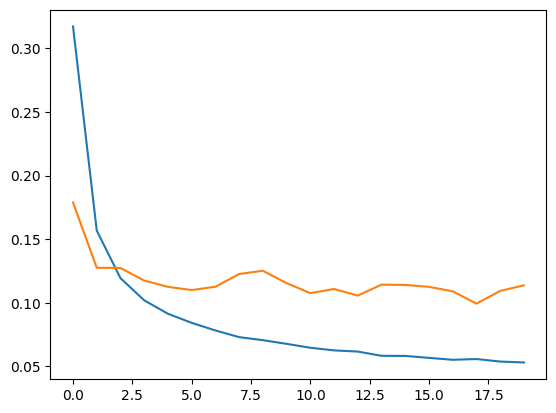

In [ ]:
plt.plot(history_l1.history['loss'])
plt.plot(history_l1.history['val_loss'])

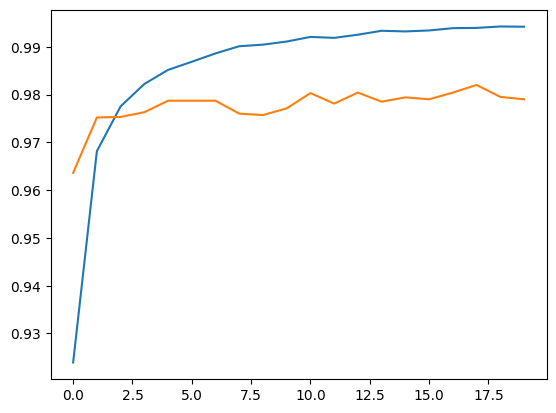

In [ ]:
plt.plot(history_l1.history['accuracy'])
plt.plot(history_l1.history['val_accuracy'])

L2

L2=0.000001

In [ ]:
# Modelo con Regularización L2 = 0.000001
# Basado en los mejores parámetros de Optuna

# Parámetros fijos de Optuna
lr = 0.0019954857471173276
optimizer = RMSprop(learning_rate=lr)

# Modelo
model_l2_1 = Sequential()
model_l2_1.add(Input(shape=(784,)))
model_l2_1.add(Dense(219,
                     activation='relu',
                     kernel_regularizer=regularizers.l2(0.000001)))
model_l2_1.add(Dense(10, activation='softmax'))

model_l2_1.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_l2_1.summary()

# MLflow
mlflow.set_experiment("Regularization_Study")

filepath = "best_model_l2_1e-6.keras"
earlystop = EarlyStopping(monitor='val_loss', mode='min',
                          restore_best_weights=True, patience=10, verbose=1)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1,
                             save_best_only=True, mode='min')

with mlflow.start_run(run_name="L2_1e-6"):
    history = model_l2_1.fit(
        x_trainv, y_trainc,
        batch_size=128,
        epochs=20,
        validation_data=(x_testv, y_testc),
        callbacks=[earlystop, checkpoint],
        verbose=1
    )

    mlflow.log_metric("final_val_accuracy",
                      max(history.history["val_accuracy"]))


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 219)            │       171,915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 10)             │         2,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,115 (680.14 KB)

 Trainable params: 174,115 (680.14 KB)

 Non-trainable params: 0 (0.00 B)

...

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9776 - loss: 0.0725 - val_accuracy: 0.9724 - val_loss: 0.0949
Epoch 4/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9859 - loss: 0.0501
Epoch 4: val_loss improved from 0.09492 to 0.08943, saving model to best_model_l2_1e-6.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9859 - loss: 0.0501 - val_accuracy: 0.9743 - val_loss: 0.0894
Epoch 5/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9882 - loss: 0.0398
Epoch 5: val_loss improved from 0.08943 to 0.07120, saving model to best_model_l2_1e-6.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9882 - loss: 0.0398 - val_accuracy: 0.9795 - val_loss: 0.0712
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9916 - loss: 0.0298
Epoch 6: val_loss did not improve from 0.07120
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9915 - loss: 0.0298 - val_accuracy: 0.9770 - val_loss: 0.0785
Epoch 7/20
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9932 - loss: 0.0225
Epoch 7: val_loss did not improve from 0.07120
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9932 - loss: 0.0226 - val_accuracy: 0.9779 - val_loss: 0.0844
Epoch 8/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9948 - loss: 0.0190
Epoch 8: val_loss did not improve from 0.07120
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9948 - loss: 0.0190 - val_accuracy: 0.9808 - val_loss: 0.0746
Epoch 9/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9960 - loss: 0.0156
Epoch 9: val_loss did not improve from 

2026/03/01 05:51:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run L2_1e-6 at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/daa9673adf254a4eaa005a147135296e
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


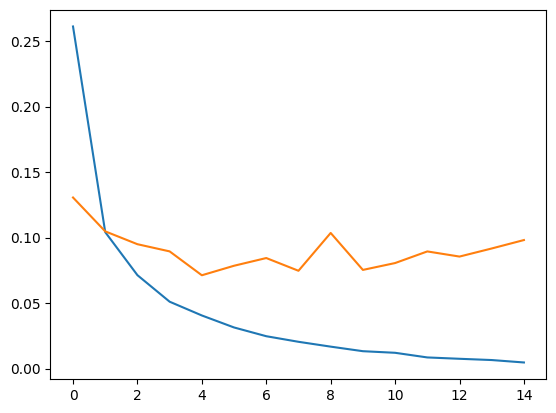

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

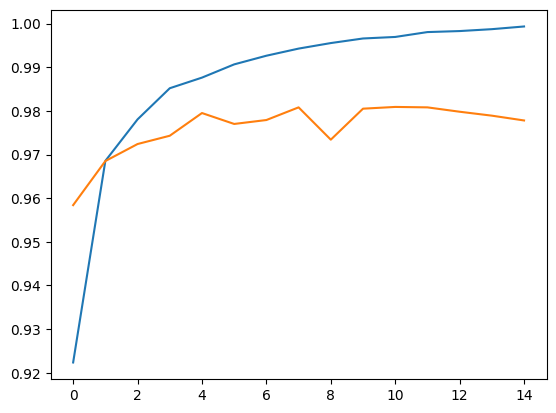

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

L2= 0.00001

In [ ]:
# Modelo con Regularización L2 = 0.00001
# Basado en los mejores parámetros de Optuna

# Parámetros fijos de Optuna
lr = 0.0019954857471173276
optimizer = RMSprop(learning_rate=lr)

# Modelo
model_l2_2 = Sequential()
model_l2_2.add(Input(shape=(784,)))
model_l2_2.add(Dense(219,
                     activation='relu',
                     kernel_regularizer=regularizers.l2(0.00001)))
model_l2_2.add(Dense(10, activation='softmax'))

model_l2_2.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_l2_2.summary()

# MLflow
mlflow.set_experiment("Regularization_Study")

filepath = "best_model_l2_1e-5.keras"
earlystop = EarlyStopping(monitor='val_loss', mode='min',
                          restore_best_weights=True, patience=10, verbose=1)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1,
                             save_best_only=True, mode='min')

with mlflow.start_run(run_name="L2_1e-5"):
    history = model_l2_2.fit(
        x_trainv, y_trainc,
        batch_size=128,
        epochs=20,
        validation_data=(x_testv, y_testc),
        callbacks=[earlystop, checkpoint],
        verbose=1
    )

    mlflow.log_metric("final_val_accuracy",
                      max(history.history["val_accuracy"]))



Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ (None, 219)            │       171,915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 10)             │         2,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,115 (680.14 KB)

 Trainable params: 174,115 (680.14 KB)

 Non-trainable params: 0 (0.00 B)

...

469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9790 - loss: 0.0746 - val_accuracy: 0.9770 - val_loss: 0.0827
Epoch 4/20
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9851 - loss: 0.0569
Epoch 4: val_loss did not improve from 0.08266
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9851 - loss: 0.0569 - val_accuracy: 0.9764 - val_loss: 0.0833
Epoch 5/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9889 - loss: 0.0443
Epoch 5: val_loss improved from 0.08266 to 0.08048, saving model to best_model_l2_1e-5.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9889 - loss: 0.0443 - val_accuracy: 0.9785 - val_loss: 0.0805
Epoch 6/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9914 - loss: 0.0375
Epoch 6: val_loss did not improve from 0.08048
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9914 - loss: 0.0375 - val_accuracy: 0.9770 - val_loss: 0.0857
Epoch 7/20
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9933 - loss: 0.0328
Epoch 7: val_loss did not improve from 0.08048
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9933 - loss: 0.0329 - val_accuracy: 0.9770 - val_loss: 0.0862
Epoch 8/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9940 - loss: 0.0294
Epoch 8: val_loss improved from 0.08048 to 0.07454, saving model to best_model_l2_1e-5.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9940 - loss: 0.0294 - val_accuracy: 0.9824 - val_loss: 0.0745
Epoch 9/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9949 - loss: 0.0272
Epoch 9: val_loss did not improve from 0.07454
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9949 - loss: 0.0272 - val_accuracy: 0.9812 - val_loss: 0.0820
Epoch 10/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9958 - loss: 0.0246
Epoch 10: val_loss did not improve from 0.07454
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9958 - loss: 0.0246 - val_accuracy: 0.9802 - val_loss: 0.0822
Epoch 11/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9968 - loss: 0.0213
Epoch 11: val_loss did not improve from 0.07454
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9968 - loss: 0.0213 - val_accuracy: 0.9817 - val_loss: 0.0828
Epoch 12/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9970 - loss: 0.0212
Epoch 12: val_loss did not improve

2026/03/01 05:55:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run L2_1e-5 at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/064e4ab81b784e2d89a19ef8874e8a47
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


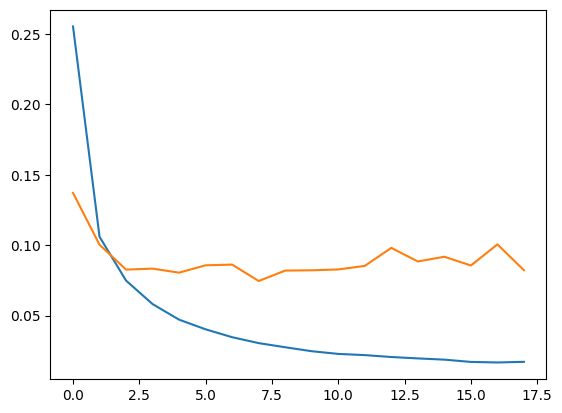

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

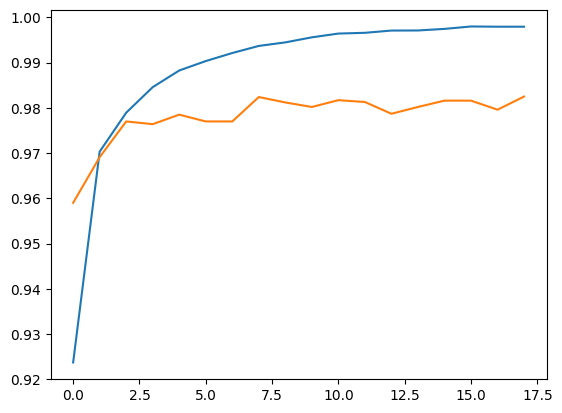

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

l2=0.0001

In [ ]:
# Modelo con Regularización L2 = 0.0001
# Basado en los mejores parámetros de Optuna

# Parámetros fijos de Optuna
lr = 0.0019954857471173276
optimizer = RMSprop(learning_rate=lr)

# Modelo
model_l2_3 = Sequential()
model_l2_3.add(Input(shape=(784,)))
model_l2_3.add(Dense(219,
                     activation='relu',
                     kernel_regularizer=regularizers.l2(0.0001)))
model_l2_3.add(Dense(10, activation='softmax'))

model_l2_3.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_l2_3.summary()

# MLflow
mlflow.set_experiment("Regularization_Study")

filepath = "best_model_l2_1e-4.keras"
earlystop = EarlyStopping(monitor='val_loss', mode='min',
                          restore_best_weights=True, patience=10, verbose=1)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1,
                             save_best_only=True, mode='min')

with mlflow.start_run(run_name="L2_1e-4"):
    history = model_l2_3.fit(
        x_trainv, y_trainc,
        batch_size=128,
        epochs=20,
        validation_data=(x_testv, y_testc),
        callbacks=[earlystop, checkpoint],
        verbose=1
    )

    mlflow.log_metric("final_val_accuracy",
                      max(history.history["val_accuracy"]))


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_70 (Dense)                │ (None, 219)            │       171,915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 10)             │         2,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,115 (680.14 KB)

 Trainable params: 174,115 (680.14 KB)

 Non-trainable params: 0 (0.00 B)

...

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9857 - loss: 0.0804 - val_accuracy: 0.9790 - val_loss: 0.1026
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9872 - loss: 0.0738
Epoch 7: val_loss did not improve from 0.10261
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9872 - loss: 0.0738 - val_accuracy: 0.9785 - val_loss: 0.1085
Epoch 8/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9893 - loss: 0.0699
Epoch 8: val_loss did not improve from 0.10261
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9893 - loss: 0.0699 - val_accuracy: 0.9763 - val_loss: 0.1095
Epoch 9/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9898 - loss: 0.0668
Epoch 9: val_loss improved from 0.10261 to 0.09926, saving model to best_model_l2_1e-4.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9898 - loss: 0.0668 - val_accuracy: 0.9794 - val_loss: 0.0993
Epoch 10/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9902 - loss: 0.0651
Epoch 10: val_loss improved from 0.09926 to 0.09850, saving model to best_model_l2_1e-4.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9902 - loss: 0.0651 - val_accuracy: 0.9794 - val_loss: 0.0985
Epoch 11/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9897 - loss: 0.0642
Epoch 11: val_loss did not improve from 0.09850
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9896 - loss: 0.0642 - val_accuracy: 0.9778 - val_loss: 0.1018
Epoch 12/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9903 - loss: 0.0614
Epoch 12: val_loss did not improve from 0.09850
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9903 - loss: 0.0614 - val_accuracy: 0.9767 - val_loss: 0.1153
Epoch 13/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9907 - loss: 0.0610
Epoch 13: val_loss did not improve from 0.09850
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9907 - loss: 0.0610 - val_accuracy: 0.9773 - val_loss: 0.1049
Epoch 14/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9908 - loss: 0.0601
Epoch 14: val_loss did not impro

2026/03/01 05:59:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run L2_1e-4 at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/a85312ec4191465199b1e4fef30dd536
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


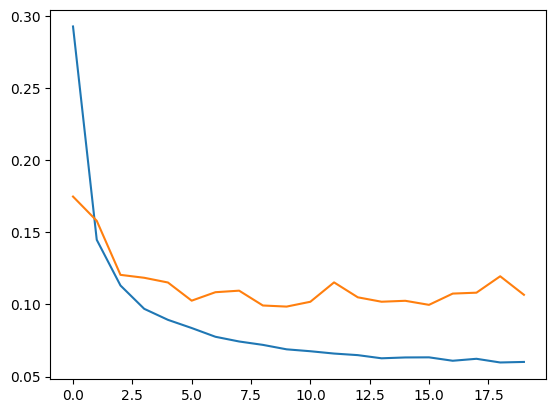

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

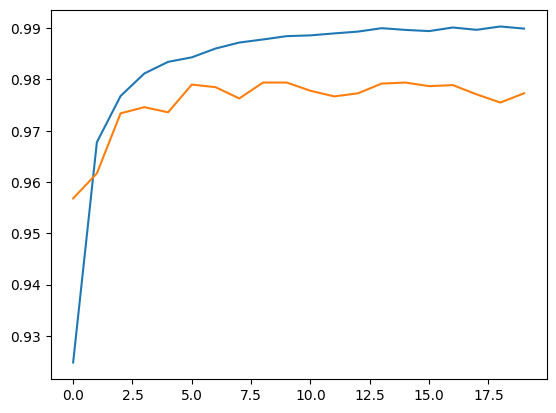

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

L1-L2

l1=0.000001, L2=0.000001

In [ ]:
# Modelo con Regularización L1-L2
# l1 = 0.000001, l2 = 0.000001
# Basado en los mejores parámetros de Optuna

# Parámetros fijos de Optuna
lr = 0.0019954857471173276
optimizer = RMSprop(learning_rate=lr)

# Modelo
model_l1_l2_1 = Sequential()
model_l1_l2_1.add(Input(shape=(784,)))
model_l1_l2_1.add(Dense(219,
                     activation='relu',
                     kernel_regularizer=regularizers.l1_l2(l1=0.000001, l2=0.000001)))
model_l1_l2_1.add(Dense(10, activation='softmax'))

model_l1_l2_1.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_l1_l2_1.summary()

# MLflow
mlflow.set_experiment("Regularization_Study")

filepath = "best_model_l1_l2_1e-6_1e-6.keras"
earlystop = EarlyStopping(monitor='val_loss', mode='min',
                          restore_best_weights=True, patience=10, verbose=1)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1,
                             save_best_only=True, mode='min')

with mlflow.start_run(run_name="L1L2_1e-6_1e-6"):
    history = model_l1_l2_1.fit(
        x_trainv, y_trainc,
        batch_size=128,
        epochs=20,
        validation_data=(x_testv, y_testc),
        callbacks=[earlystop, checkpoint],
        verbose=1
    )

    mlflow.log_metric("final_val_accuracy",
                      max(history.history["val_accuracy"]))


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 219)            │       171,915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 10)             │         2,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,115 (680.14 KB)

 Trainable params: 174,115 (680.14 KB)

 Non-trainable params: 0 (0.00 B)

...

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9848 - loss: 0.0595 - val_accuracy: 0.9768 - val_loss: 0.0847
Epoch 5/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9880 - loss: 0.0480
Epoch 5: val_loss improved from 0.08473 to 0.08195, saving model to best_model_l1_l2_1e-6_1e-6.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9879 - loss: 0.0480 - val_accuracy: 0.9781 - val_loss: 0.0819
Epoch 6/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9910 - loss: 0.0390
Epoch 6: val_loss did not improve from 0.08195
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9910 - loss: 0.0391 - val_accuracy: 0.9783 - val_loss: 0.0881
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9930 - loss: 0.0339
Epoch 7: val_loss did not improve from 0.08195
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9930 - loss: 0.0339 - val_accuracy: 0.9799 - val_loss: 0.0865
Epoch 8/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9948 - loss: 0.0282
Epoch 8: val_loss did not improve from 0.08195
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9948 - loss: 0.0282 - val_accuracy: 0.9800 - val_loss: 0.0855
Epoch 9/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9960 - loss: 0.0248
Epoch 9: val_loss improved from 0.08195

469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9960 - loss: 0.0248 - val_accuracy: 0.9826 - val_loss: 0.0800
Epoch 10/20
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9967 - loss: 0.0227
Epoch 10: val_loss did not improve from 0.07996
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9967 - loss: 0.0227 - val_accuracy: 0.9799 - val_loss: 0.0867
Epoch 11/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9973 - loss: 0.0197
Epoch 11: val_loss did not improve from 0.07996
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9973 - loss: 0.0197 - val_accuracy: 0.9821 - val_loss: 0.0849
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9977 - loss: 0.0187
Epoch 12: val_loss did not improve from 0.07996
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9977 - loss: 0.0187 - val_accuracy: 0.9805 - val_loss: 0.0934
Epoch 13/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9983 - loss: 0.0169
Epoch 13: val_loss did not impro

2026/03/01 06:06:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run L1L2_1e-6_1e-6 at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/0557e4bd19c549aaabd3d30d4be2e181
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


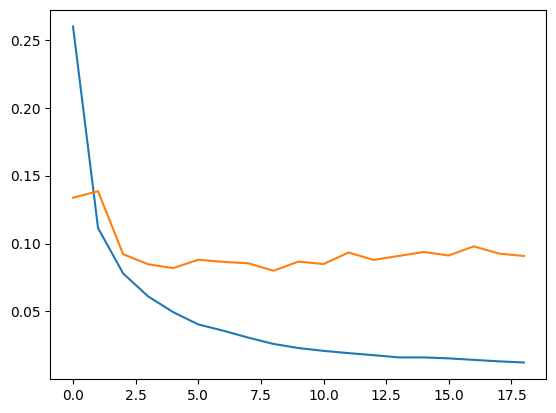

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

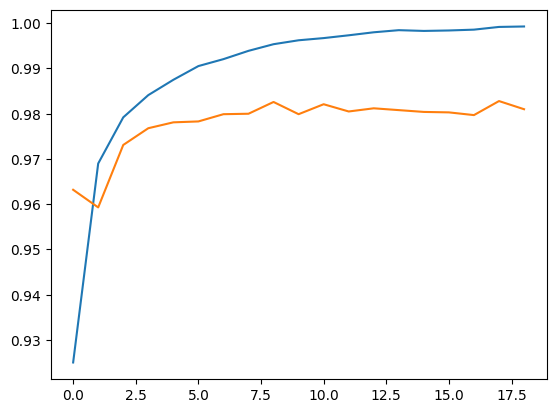

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

Dropout

Dropout=0.1

In [ ]:
# Modelo con Dropout = 0.1
# Basado en los mejores parámetros de Optuna


# Parámetros fijos de Optuna
lr = 0.0019954857471173276
optimizer = RMSprop(learning_rate=lr)

# Modelo
model_dropout_1 = Sequential()
model_dropout_1.add(Input(shape=(784,)))
model_dropout_1.add(Dense(219, activation='relu'))
model_dropout_1.add(Dropout(0.1))
model_dropout_1.add(Dense(10, activation='softmax'))

model_dropout_1.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_dropout_1.summary()

# MLflow
mlflow.set_experiment("Regularization_Study")

filepath = "best_model_dropout_0.1.keras"
earlystop = EarlyStopping(monitor='val_loss', mode='min',
                          restore_best_weights=True, patience=10, verbose=1)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1,
                             save_best_only=True, mode='min')

with mlflow.start_run(run_name="Dropout_0.1"):
    history = model_dropout_1.fit(
        x_trainv, y_trainc,
        batch_size=128,
        epochs=20,
        validation_data=(x_testv, y_testc),
        callbacks=[earlystop, checkpoint],
        verbose=1
    )

    mlflow.log_metric("final_val_accuracy",
                      max(history.history["val_accuracy"]))

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_74 (Dense)                │ (None, 219)            │       171,915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 219)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 10)             │         2,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,115 (680.14 KB)

 Trainable params: 174,115 (680.14 KB)

 Non-trainable params: 0 (0.00 B)

...

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9841 - loss: 0.0485 - val_accuracy: 0.9804 - val_loss: 0.0675
Epoch 6/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9874 - loss: 0.0391
Epoch 6: val_loss did not improve from 0.06753
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9874 - loss: 0.0391 - val_accuracy: 0.9794 - val_loss: 0.0677
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9891 - loss: 0.0328
Epoch 7: val_loss improved from 0.06753 to 0.06613, saving model to best_model_dropout_0.1.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9891 - loss: 0.0328 - val_accuracy: 0.9803 - val_loss: 0.0661
Epoch 8/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9903 - loss: 0.0318
Epoch 8: val_loss improved from 0.06613 to 0.06094, saving model to best_model_dropout_0.1.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9903 - loss: 0.0318 - val_accuracy: 0.9822 - val_loss: 0.0609
Epoch 9/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9922 - loss: 0.0243
Epoch 9: val_loss did not improve from 0.06094
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9922 - loss: 0.0243 - val_accuracy: 0.9812 - val_loss: 0.0690
Epoch 10/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9927 - loss: 0.0217
Epoch 10: val_loss did not improve from 0.06094
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9927 - loss: 0.0217 - val_accuracy: 0.9802 - val_loss: 0.0758
Epoch 11/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9943 - loss: 0.0181
Epoch 11: val_loss did not improve from 0.06094
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9943 - loss: 0.0181 - val_accuracy: 0.9818 - val_loss: 0.0691
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9947 - loss: 0.0163
Epoch 12: val_loss did not improve

2026/03/01 06:14:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Dropout_0.1 at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/509eec6699f14c4ca812cdaa68a3f460
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


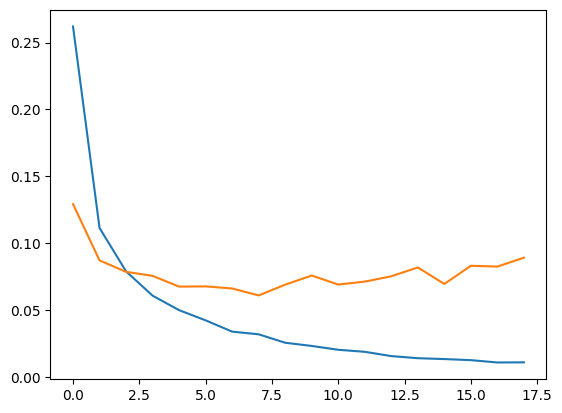

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

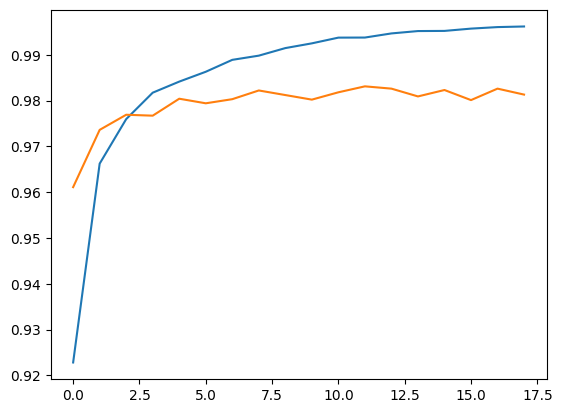

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

Dropout=0.3

In [ ]:
# Modelo con Dropout = 0.3
# Basado en los mejores parámetros de Optuna

# Parámetros fijos de Optuna
lr = 0.0019954857471173276
optimizer = RMSprop(learning_rate=lr)

# Modelo
model_dropout_2 = Sequential()
model_dropout_2.add(Input(shape=(784,)))
model_dropout_2.add(Dense(219, activation='relu'))
model_dropout_2.add(Dropout(0.3))
model_dropout_2.add(Dense(10, activation='softmax'))

model_dropout_2.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_dropout_2.summary()

# MLflow
mlflow.set_experiment("Regularization_Study")

filepath = "best_model_dropout_0.3.keras"
earlystop = EarlyStopping(monitor='val_loss', mode='min',
                          restore_best_weights=True, patience=10, verbose=1)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1,
                             save_best_only=True, mode='min')

with mlflow.start_run(run_name="Dropout_0.3"):
    history = model_dropout_2.fit(
        x_trainv, y_trainc,
        batch_size=128,
        epochs=20,
        validation_data=(x_testv, y_testc),
        callbacks=[earlystop, checkpoint],
        verbose=1
    )

    mlflow.log_metric("final_val_accuracy",
                      max(history.history["val_accuracy"]))

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_76 (Dense)                │ (None, 219)            │       171,915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 219)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 10)             │         2,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,115 (680.14 KB)

 Trainable params: 174,115 (680.14 KB)

 Non-trainable params: 0 (0.00 B)

...

469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9806 - loss: 0.0604 - val_accuracy: 0.9802 - val_loss: 0.0702
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9825 - loss: 0.0570
Epoch 8: val_loss did not improve from 0.07021
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9825 - loss: 0.0570 - val_accuracy: 0.9795 - val_loss: 0.0790
Epoch 9/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9836 - loss: 0.0507
Epoch 9: val_loss did not improve from 0.07021
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9836 - loss: 0.0507 - val_accuracy: 0.9797 - val_loss: 0.0753
Epoch 10/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9850 - loss: 0.0456
Epoch 10: val_loss did not improve from 0.07021
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9850 - loss: 0.0456 - val_accuracy: 0.9799 - val_loss: 0.0733
Epoch 11/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9847 - loss: 0.0460
Epoch 11: val_loss improved from 0.0

469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9847 - loss: 0.0460 - val_accuracy: 0.9807 - val_loss: 0.0691
Epoch 12/20
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9861 - loss: 0.0434
Epoch 12: val_loss improved from 0.06911 to 0.06564, saving model to best_model_dropout_0.3.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9861 - loss: 0.0434 - val_accuracy: 0.9817 - val_loss: 0.0656
Epoch 13/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9873 - loss: 0.0398
Epoch 13: val_loss did not improve from 0.06564
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9873 - loss: 0.0398 - val_accuracy: 0.9816 - val_loss: 0.0697
Epoch 14/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9887 - loss: 0.0355
Epoch 14: val_loss did not improve from 0.06564
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9887 - loss: 0.0356 - val_accuracy: 0.9828 - val_loss: 0.0674
Epoch 15/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9890 - loss: 0.0346
Epoch 15: val_loss did not improve from 0.06564
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9890 - loss: 0.0346 - val_accuracy: 0.9812 - val_loss: 0.0773
Epoch 16/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9888 - loss: 0.0350
Epoch 16: val_loss did not impro

2026/03/01 06:19:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Dropout_0.3 at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/4f4a752e6f134b66b8580a337f23810a
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


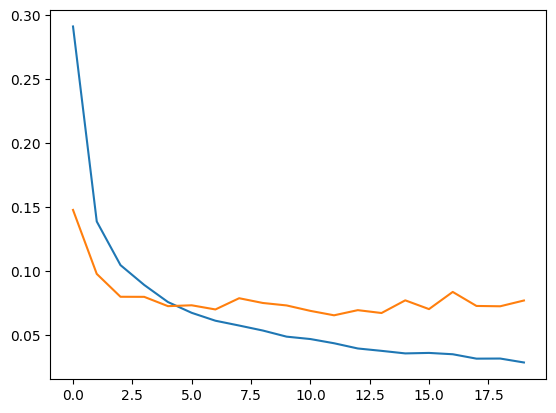

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

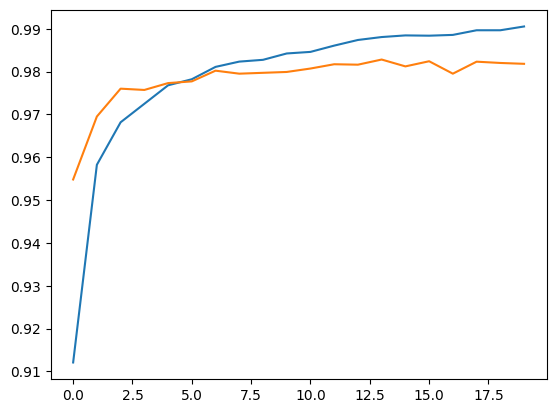

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

Dropout + l1-12

Dropout=0.3 + l1-12 =0.000001,0.000001

In [ ]:
# Modelo con Dropout = 0.3 y L1-L2 = (0.000001, 0.000001)
# Basado en los mejores parámetros de Optuna

# Parámetros fijos de Optuna
lr = 0.0019954857471173276
optimizer = RMSprop(learning_rate=lr)

# Modelo
model_dropout_l1l2_1 = Sequential()
model_dropout_l1l2_1.add(Input(shape=(784,)))
model_dropout_l1l2_1.add(Dense(219,
                               activation='relu',
                               kernel_regularizer=regularizers.l1_l2(l1=0.000001, l2=0.000001)))
model_dropout_l1l2_1.add(Dropout(0.3))
model_dropout_l1l2_1.add(Dense(10, activation='softmax'))

model_dropout_l1l2_1.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_dropout_l1l2_1.summary()

# MLflow
mlflow.set_experiment("Regularization_Study")

filepath = "best_model_dropout03_l1l2_1e-6.keras"
earlystop = EarlyStopping(monitor='val_loss', mode='min',
                          restore_best_weights=True, patience=10, verbose=1)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1,
                             save_best_only=True, mode='min')

with mlflow.start_run(run_name="Dropout03_L1L2_1e-6"):
    history = model_dropout_l1l2_1.fit(
        x_trainv, y_trainc,
        batch_size=128,
        epochs=20,
        validation_data=(x_testv, y_testc),
        callbacks=[earlystop, checkpoint],
        verbose=1
    )

    mlflow.log_metric("final_val_accuracy",
                      max(history.history["val_accuracy"]))

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_78 (Dense)                │ (None, 219)            │       171,915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 219)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 10)             │         2,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,115 (680.14 KB)

 Trainable params: 174,115 (680.14 KB)

 Non-trainable params: 0 (0.00 B)

...

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9682 - loss: 0.1125 - val_accuracy: 0.9749 - val_loss: 0.0893
Epoch 4/20
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9740 - loss: 0.0959
Epoch 4: val_loss did not improve from 0.08926
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9740 - loss: 0.0960 - val_accuracy: 0.9762 - val_loss: 0.0914
Epoch 5/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9761 - loss: 0.0845
Epoch 5: val_loss improved from 0.08926 to 0.07618, saving model to best_model_dropout03_l1l2_1e-6.keras


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9761 - loss: 0.0845 - val_accuracy: 0.9793 - val_loss: 0.0762
Epoch 6/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9795 - loss: 0.0778
Epoch 6: val_loss did not improve from 0.07618
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9795 - loss: 0.0778 - val_accuracy: 0.9803 - val_loss: 0.0769
Epoch 7/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9805 - loss: 0.0686
Epoch 7: val_loss did not improve from 0.07618
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9805 - loss: 0.0686 - val_accuracy: 0.9803 - val_loss: 0.0815
Epoch 8/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9826 - loss: 0.0655
Epoch 8: val_loss did not improve from 0.07618
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9826 - loss: 0.0656 - val_accuracy: 0.9816 - val_loss: 0.0762
Epoch 9/20
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9840 - loss: 0.0629
Epoch 9: val_loss improved from 0.07618

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9839 - loss: 0.0629 - val_accuracy: 0.9814 - val_loss: 0.0758
Epoch 10/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9833 - loss: 0.0616
Epoch 10: val_loss did not improve from 0.07576
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9833 - loss: 0.0616 - val_accuracy: 0.9806 - val_loss: 0.0812
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9863 - loss: 0.0555
Epoch 11: val_loss did not improve from 0.07576
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9863 - loss: 0.0555 - val_accuracy: 0.9821 - val_loss: 0.0788
Epoch 12/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9855 - loss: 0.0548
Epoch 12: val_loss did not improve from 0.07576
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9855 - loss: 0.0548 - val_accuracy: 0.9828 - val_loss: 0.0821
Epoch 13/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9873 - loss: 0.0509
Epoch 13: val_loss did not impro

2026/03/01 06:32:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Dropout03_L1L2_1e-6 at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/183d4e79575f425b9afed58a6799fc7f
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


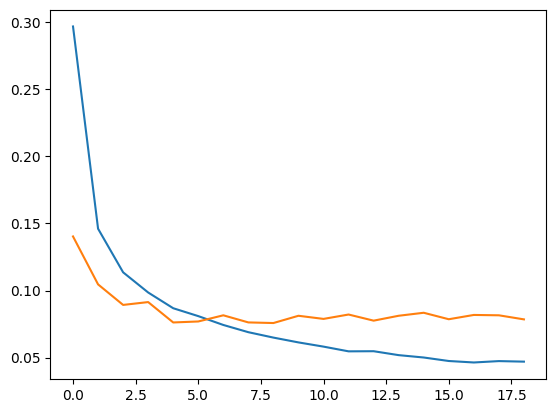

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

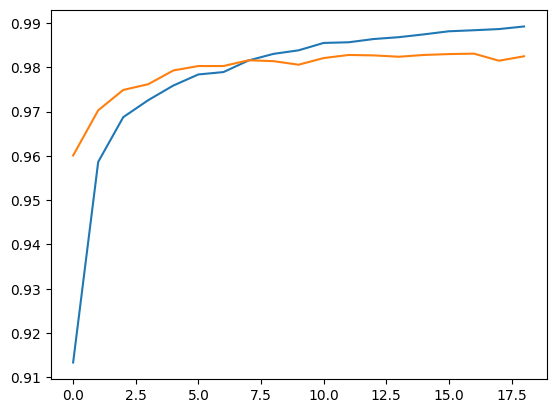

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

Dropout=0.4 + l1-12 =0.00001,0.00001

In [ ]:
# Modelo con Dropout = 0.4 y L1-L2 = (0.00001, 0.00001)
# Basado en los mejores parámetros de Optuna

# Parámetros fijos de Optuna
lr = 0.0019954857471173276
optimizer = RMSprop(learning_rate=lr)

# Modelo
model_dropout_l1l2_2 = Sequential()
model_dropout_l1l2_2.add(Input(shape=(784,)))
model_dropout_l1l2_2.add(Dense(219,
                               activation='relu',
                               kernel_regularizer=regularizers.l1_l2(l1=0.00001, l2=0.00001)))
model_dropout_l1l2_2.add(Dropout(0.4))
model_dropout_l1l2_2.add(Dense(10, activation='softmax'))

model_dropout_l1l2_2.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_dropout_l1l2_2.summary()

# MLflow
mlflow.set_experiment("Regularization_Study")

filepath = "best_model_dropout04_l1l2_1e-5.keras"
earlystop = EarlyStopping(monitor='val_loss', mode='min',
                          restore_best_weights=True, patience=10, verbose=1)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1,
                             save_best_only=True, mode='min')

with mlflow.start_run(run_name="Dropout04_L1L2_1e-5"):
    history = model_dropout_l1l2_2.fit(
        x_trainv, y_trainc,
        batch_size=128,
        epochs=20,
        validation_data=(x_testv, y_testc),
        callbacks=[earlystop, checkpoint],
        verbose=1
    )

    mlflow.log_metric("final_val_accuracy",
                      max(history.history["val_accuracy"]))

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_80 (Dense)                │ (None, 219)            │       171,915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 219)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 10)             │         2,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,115 (680.14 KB)

 Trainable params: 174,115 (680.14 KB)

 Non-trainable params: 0 (0.00 B)

...

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9745 - loss: 0.1358 - val_accuracy: 0.9803 - val_loss: 0.1164
Epoch 9/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9731 - loss: 0.1364
Epoch 9: val_loss did not improve from 0.11641
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9731 - loss: 0.1364 - val_accuracy: 0.9787 - val_loss: 0.1258
Epoch 10/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9736 - loss: 0.1345
Epoch 10: val_loss did not improve from 0.11641
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9736 - loss: 0.1345 - val_accuracy: 0.9793 - val_loss: 0.1222
Epoch 11/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9762 - loss: 0.1305
Epoch 11: val_loss did not improve from 0.11641
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9762 - loss: 0.1306 - val_accuracy: 0.9785 - val_loss: 0.1264
Epoch 12/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9754 - loss: 0.1282
Epoch 12: val_loss did not improve

469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9760 - loss: 0.1268 - val_accuracy: 0.9816 - val_loss: 0.1137
Epoch 16/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9756 - loss: 0.1251
Epoch 16: val_loss did not improve from 0.11368
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9756 - loss: 0.1251 - val_accuracy: 0.9783 - val_loss: 0.1257
Epoch 17/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9760 - loss: 0.1253
Epoch 17: val_loss did not improve from 0.11368
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9760 - loss: 0.1254 - val_accuracy: 0.9791 - val_loss: 0.1201
Epoch 18/20
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9763 - loss: 0.1266
Epoch 18: val_loss did not improve from 0.11368
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9763 - loss: 0.1266 - val_accuracy: 0.9798 - val_loss: 0.1193
Epoch 19/20
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9769 - loss: 0.1233
Epoch 19: val_loss did not imp

469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9782 - loss: 0.1211 - val_accuracy: 0.9809 - val_loss: 0.1128
Restoring model weights from the end of the best epoch: 20.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


2026/03/01 06:41:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Dropout04_L1L2_1e-5 at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1/runs/500eb0d98db14627a90ec572ba4a2a3b
🧪 View experiment at: https://dagshub.com/CrUz-035/tarea_3.mlflow/#/experiments/1


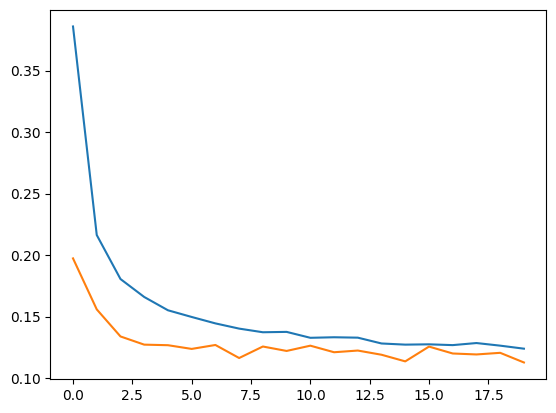

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

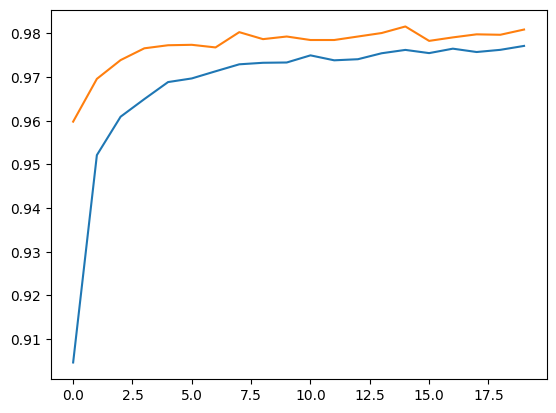

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])